# Context-conditioned midpoint loss: does it prevent the price jump?

The generator now learns from a **real 48-event prefix**, then generates the
next **16 events using its own previous predictions**. Its decoded standardized
log midpoint is compared with the actual training continuation. This adds
`weight × midpoint MSE` to the existing adversarial and latent-transition losses.
The embedder and decoder are frozen during this generator update; the decoder
still passes gradients back to the generator. Future observations are targets
only. Noise restarts at zero, with the same per-event Wiener increment variance.

We compare **loss weights 10 and 100** with the previous **D rate 1e-4** run.
All runs use G/E/R learning rates 3e-4, D learning rate 1e-4, seed 0, identical
real-batch order, the original architecture, and 1,000 reconstruction, 1,000
transition, and 5,000 joint updates. The existing noise is reused by the new
loss, so it consumes no additional random draws. Only the joint generator
objective changes. Price is the only feature directly supervised by this term.

Diagnostics retain the current notebook's 64-event context length and use
eight real starting contexts with 32 paired noisy completions per context.
The training loss uses 48 context events so that 16 targets fit inside each
existing 64-event training window. Training never uses validation events. Later validation contexts
include only observations preceding their own forecast. Zero-noise paths
expose deterministic drift. Each model has a full-day chart plus an early zoom.
Long continuations extend far beyond the 16-event supervised horizon and retain
training increment variance, so Wiener input variance increases with duration.
The shaded region is one standard deviation across completions.

This experiment uses one training seed. Squared error can favor smoother
prices; reducing the jump does not establish realistic book dynamics or
calibrated uncertainty.


In [1]:
from pathlib import Path
import sys
import json

project_dir = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "dataset.py").exists()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Launch from the recognition project.")
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dataset import LOBSTERLevel10Dataset

RESULTS_DIR = project_dir / "runs" / "context_loss"
EXPERIMENTS = ["reference_discriminator_1e-4", "context_weight_10_horizon_16", "context_weight_100_horizon_16"]
LABELS = {
    "reference_discriminator_1e-4": "Without context loss (D rate 1e-4)",
    "context_weight_10_horizon_16": "Context price loss: weight 10",
    "context_weight_100_horizon_16": "Context price loss: weight 100",
}
(RESULTS_DIR / "figures").mkdir(exist_ok=True)

DIRECTORIES = {name: RESULTS_DIR / f"{name}_seed_0" for name in EXPERIMENTS}
if not DIRECTORIES[EXPERIMENTS[0]].exists():
    DIRECTORIES[EXPERIMENTS[0]] = project_dir / "runs/training_balance/discriminator_1e-4_seed_0"


In [2]:
results = {}
summary_rows = []
snapshot_rows = []
for name in EXPERIMENTS:
    directory = DIRECTORIES[name]
    metadata = json.loads((directory / "run.json").read_text())
    step = metadata["training_config"]["joint_steps"]
    final_path = directory / "diagnostics_final.json"
    if not final_path.exists():
        # Older reference runs predate the 16-event metrics; recompute with paired noise.
        from training_balance_experiment import diagnostics
        from train import TrainingConfig
        from predict import load_checkpoint
        model, checkpoint = load_checkpoint(directory / "model.pt")
        model_config = TrainingConfig(**checkpoint["training_config"])
        measured, curves, _ = diagnostics(model, LOBSTERLevel10Dataset(True),
                                          LOBSTERLevel10Dataset(False), model_config)
        final_path.write_text(json.dumps({"metrics": measured, "curves": curves}, indent=2) + "\n")
    diagnostic = json.loads(final_path.read_text())
    with np.load(directory / "completion_midpoints.npz") as archive:
        full_curves = {key: archive[key].copy() for key in archive.files}
    history = pd.read_csv(directory / "losses.csv")
    final_losses = history.loc[history["stage"] == "joint"].tail(100)
    results[name] = {
        "metadata": metadata, "diagnostic": diagnostic, "full": full_curves,
        "contexts": pd.read_csv(directory / f"contexts_step_{step}.csv"),
    }
    summary_rows.append({
        "experiment": LABELS[name],
        **diagnostic["metrics"],
        "boundary_peak_mean_rise_64_dollars": max(0.0, max(diagnostic["curves"]["generated_mean"][:64])
                                                    - diagnostic["curves"]["starting_price_dollars"]),
        "boundary_max_mean_abs_error_64_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"][:64])
            - np.array(diagnostic["curves"]["observed"][:64])))),
        "boundary_max_mean_abs_error_128_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"])
            - np.array(diagnostic["curves"]["observed"])))),
        "discriminator_learning_rate": metadata["training_config"]["discriminator_learning_rate"],
        "context_loss_weight": metadata["training_config"].get("context_loss_weight", 0),
        "last100_discriminator_loss": final_losses["discriminator"].mean(),
        "last100_generator_adversarial_loss": final_losses["adversarial"].mean(),
        "training_minutes": metadata["training_seconds"] / 60,
    })
    snapshots = pd.read_csv(directory / "snapshots.csv")
    snapshots["experiment"] = LABELS[name]
    snapshot_rows.extend(snapshots.to_dict("records"))

summary = pd.DataFrame(summary_rows).set_index("experiment")
snapshots = pd.DataFrame(snapshot_rows)
summary.to_csv(RESULTS_DIR / "summary.csv")
snapshots.to_csv(RESULTS_DIR / "all_snapshots.csv", index=False)
display(summary[[
    "context_loss_weight", "discriminator_learning_rate", "training_minutes",
]].round(6))


,context_loss_weight,discriminator_learning_rate,training_minutes
experiment,,,
Without context loss (D rate 1e-4),0.0,0.0001,17.171269
Context price loss: weight 10,10.0,0.0001,11.094557
Context price loss: weight 100,100.0,0.0001,11.091702


## Short-horizon accuracy and persistence

The 16-event horizon is directly supervised during training. The 64-event
endpoint tests whether improvement lasts beyond it. Across-context error is the
absolute error of the ensemble mean endpoint, averaged across eight forecasts.
The peak-rise column catches overshoot even if price subsequently falls back.


In [3]:
display(summary[[
    "boundary_first_event_change_dollars",
    "boundary_16_event_change_dollars",
    "context_mean_abs_16_event_error_dollars",
    "boundary_peak_mean_rise_64_dollars",
    "boundary_max_mean_abs_error_64_dollars",
    "boundary_64_event_change_dollars",
    "boundary_64_event_std_dollars",
    "boundary_zero_noise_64_event_change_dollars",
    "context_mean_abs_64_event_error_dollars",
]].rename(columns={
    "boundary_first_event_change_dollars": "First-event change ($)",
    "boundary_16_event_change_dollars": "16-event change ($)",
    "context_mean_abs_16_event_error_dollars": "Eight-context 16-event error ($)",
    "boundary_peak_mean_rise_64_dollars": "Peak mean rise in first 64 events ($)",
    "boundary_max_mean_abs_error_64_dollars": "Largest mean error in first 64 events ($)",
    "boundary_64_event_change_dollars": "64-event change ($)",
    "boundary_64_event_std_dollars": "Endpoint SD ($)",
    "boundary_zero_noise_64_event_change_dollars": "Zero-noise 64-event change ($)",
    "context_mean_abs_64_event_error_dollars": "Eight-context endpoint error ($)",
}).round(4))
observed_change = results[EXPERIMENTS[0]]["diagnostic"]["metrics"]["boundary_observed_64_event_change_dollars"]
print(f"Actual observed change over the first 64 validation events: {observed_change:+.4f} dollars")


,First-event change ($),16-event change ($),Eight-context 16-event error ($),Peak mean rise in first 64 events ($),Largest mean error in first 64 events ($),64-event change ($),Endpoint SD ($),Zero-noise 64-event change ($),Eight-context endpoint error ($)
experiment,,,,,,,,,
Without context loss (D rate 1e-4),0.0672,0.5514,0.6123,1.2094,1.2094,1.2094,0.5624,1.065,1.5030
Context price loss: weight 10,-0.0125,0.2216,0.1821,0.9869,0.9869,0.9869,0.4241,1.115,0.9485
Context price loss: weight 100,0.0158,-0.0305,0.0193,0.5336,0.5336,0.5336,0.8980,-0.040,0.5160


Actual observed change over the first 64 validation events: +0.0000 dollars


In [4]:
training = LOBSTERLevel10Dataset(train=True)
validation = LOBSTERLevel10Dataset(train=False)

def midpoint(book):
    return ((book["ASKp1"] + book["BIDp1"]) / 20_000).to_numpy()

training_price = midpoint(training.books)
validation_price = midpoint(validation.books)
boundary, horizon = len(training), len(validation)

full_arrays = [training_price, validation_price]
early_arrays = []
for result in results.values():
    full_arrays.extend([result["full"]["noisy"].ravel(), result["full"]["zero"]])
    curves = result["diagnostic"]["curves"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    early_arrays.extend([np.array(curves["observed"]), np.array(curves["zero_noise"]),
                         mean - std, mean + std, np.array([curves["starting_price_dollars"]])])

def price_limits(arrays):
    low = min(array.min() for array in arrays)
    high = max(array.max() for array in arrays)
    margin = max(0.05 * (high - low), 0.01)
    return low - margin, high + margin

full_limits, early_limits = price_limits(full_arrays), price_limits(early_arrays)


def plot_experiment(name):
    result = results[name]
    fig, axes = plt.subplots(
        1, 2, figsize=(17, 5), width_ratios=[1.7, 1], layout="constrained",
    )
    ax = axes[0]
    ax.plot(np.arange(boundary), training_price, color="tab:blue", label="Training")
    ax.plot(np.arange(boundary, boundary + horizon), validation_price,
            color="tab:orange", label="Validation")
    events = np.arange(boundary - 1, boundary + horizon)
    for index, prices in enumerate(result["full"]["noisy"]):
        ax.plot(events, np.r_[training_price[-1], prices], color="tab:green", alpha=0.5,
                label="Three completions" if index == 0 else None)
    ax.plot(events, np.r_[training_price[-1], result["full"]["zero"]],
            color="black", linestyle="--", linewidth=1, label="Zero noise")
    ax.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=1)
    ax.set(title="Whole-day midpoint and completions", xlabel="Event index",
           ylabel="Midpoint ($)", ylim=full_limits)
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.legend(fontsize=9)

    ax = axes[1]
    curves = result["diagnostic"]["curves"]
    start = curves["starting_price_dollars"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    events = np.arange(len(mean) + 1)
    ax.plot(events, np.r_[start, curves["observed"]], color="tab:orange", label="Observed")
    ax.plot(events, np.r_[start, mean], color="tab:green", label="Mean of 32 completions")
    ax.fill_between(events, np.r_[start, mean - std], np.r_[start, mean + std],
                    color="tab:green", alpha=0.15, label="One completion SD")
    ax.plot(events, np.r_[start, curves["zero_noise"]], color="black",
            linestyle="--", label="Zero noise")
    ax.axvline(16, color="gray", linestyle=":", linewidth=1, label="Trained rollout horizon")
    ax.axvline(64, color="gray", linestyle=":", linewidth=1)
    ax.set(title="First 128 generated events", xlabel="Events after training boundary",
           ylabel="Midpoint ($)", ylim=early_limits)
    ax.legend(fontsize=9)
    fig.suptitle(LABELS[name])
    fig.savefig(RESULTS_DIR / "figures" / f"{name}.png", dpi=140)
    plt.show()


## Reference without the added loss


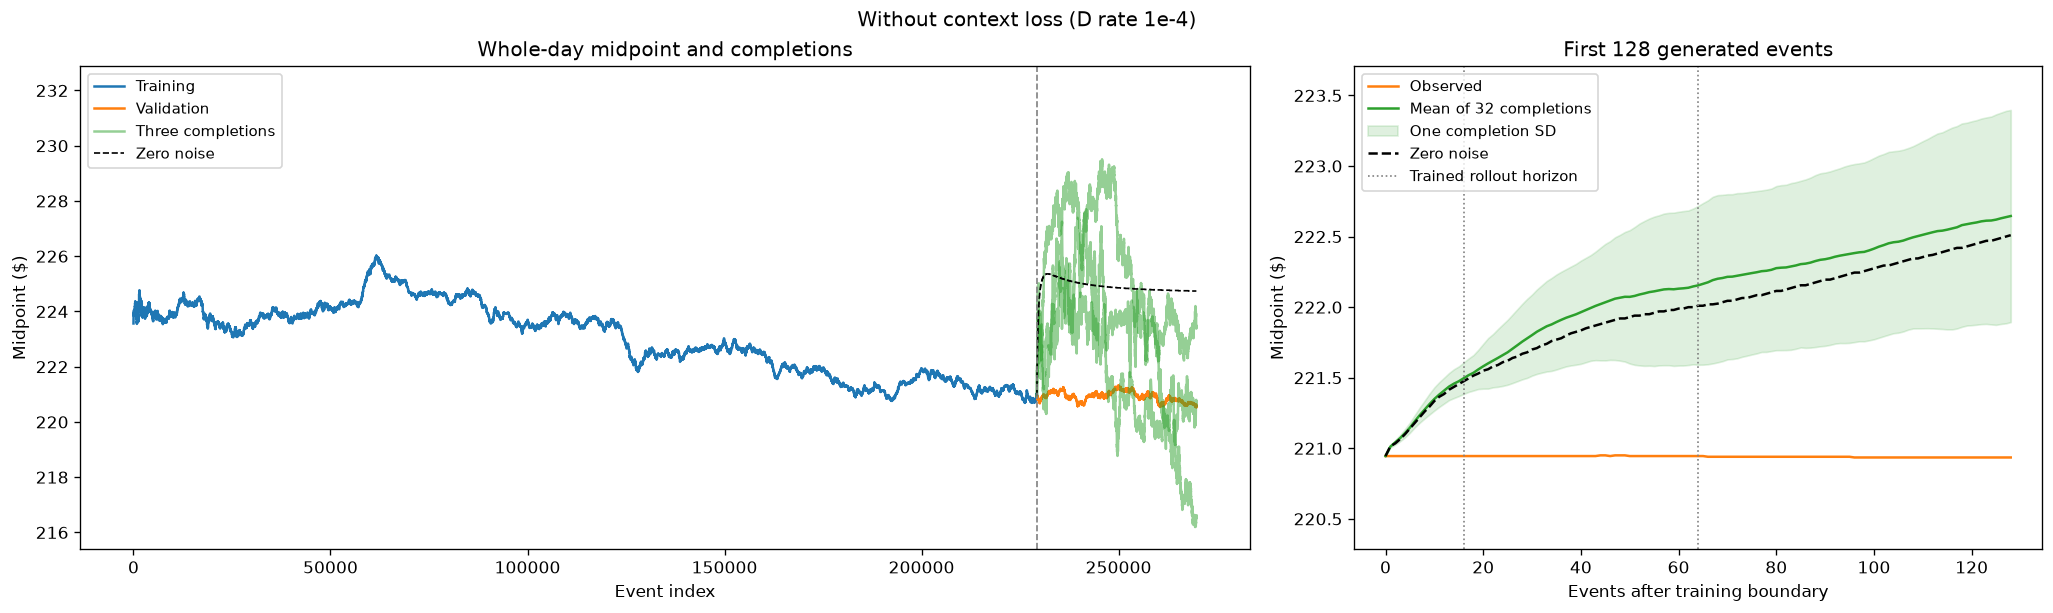

In [5]:
plot_experiment("reference_discriminator_1e-4")


## Context price loss: weight 10


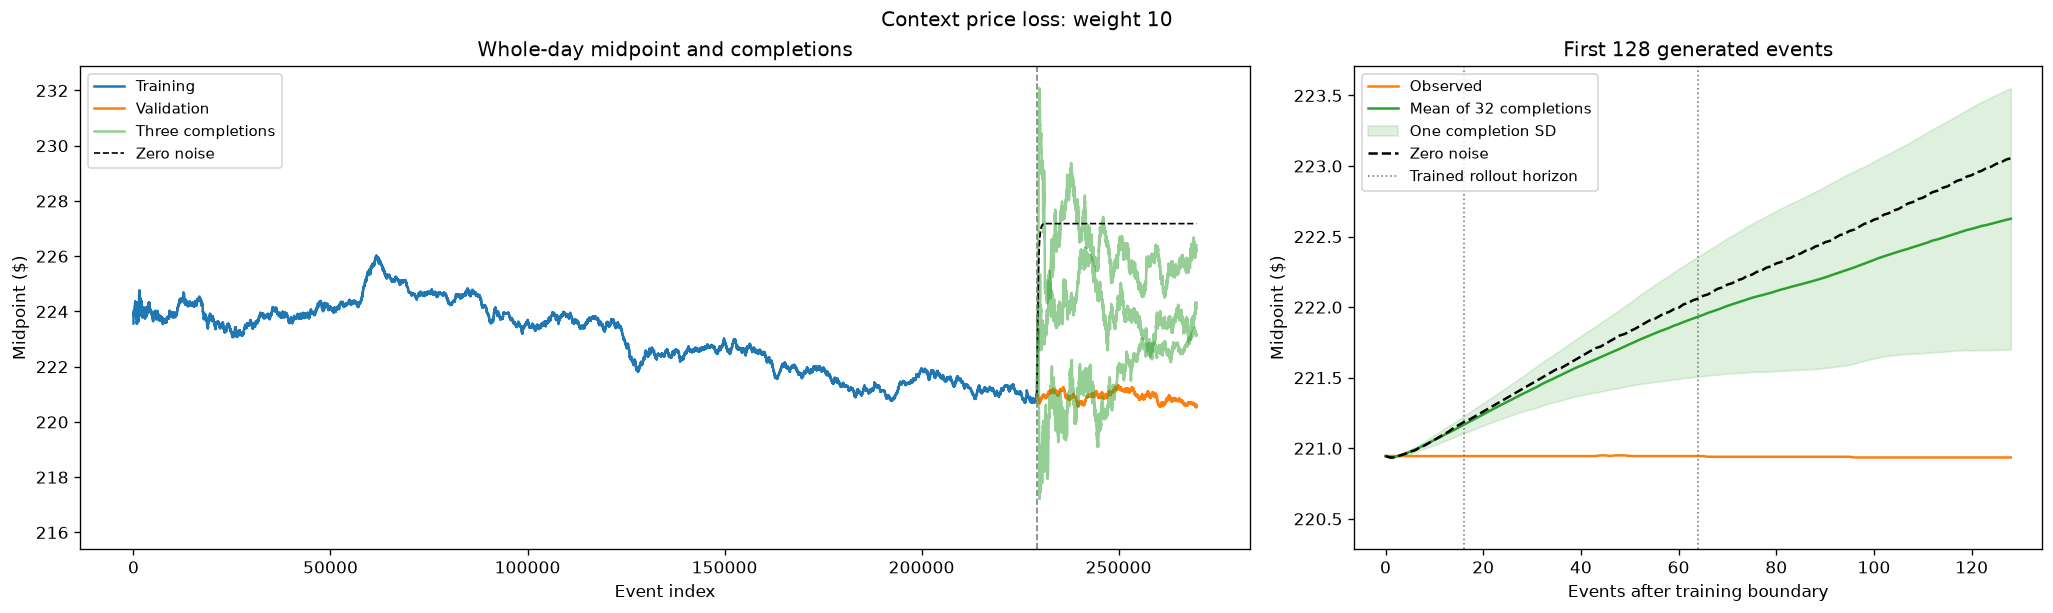

In [6]:
plot_experiment("context_weight_10_horizon_16")


## Context price loss: weight 100


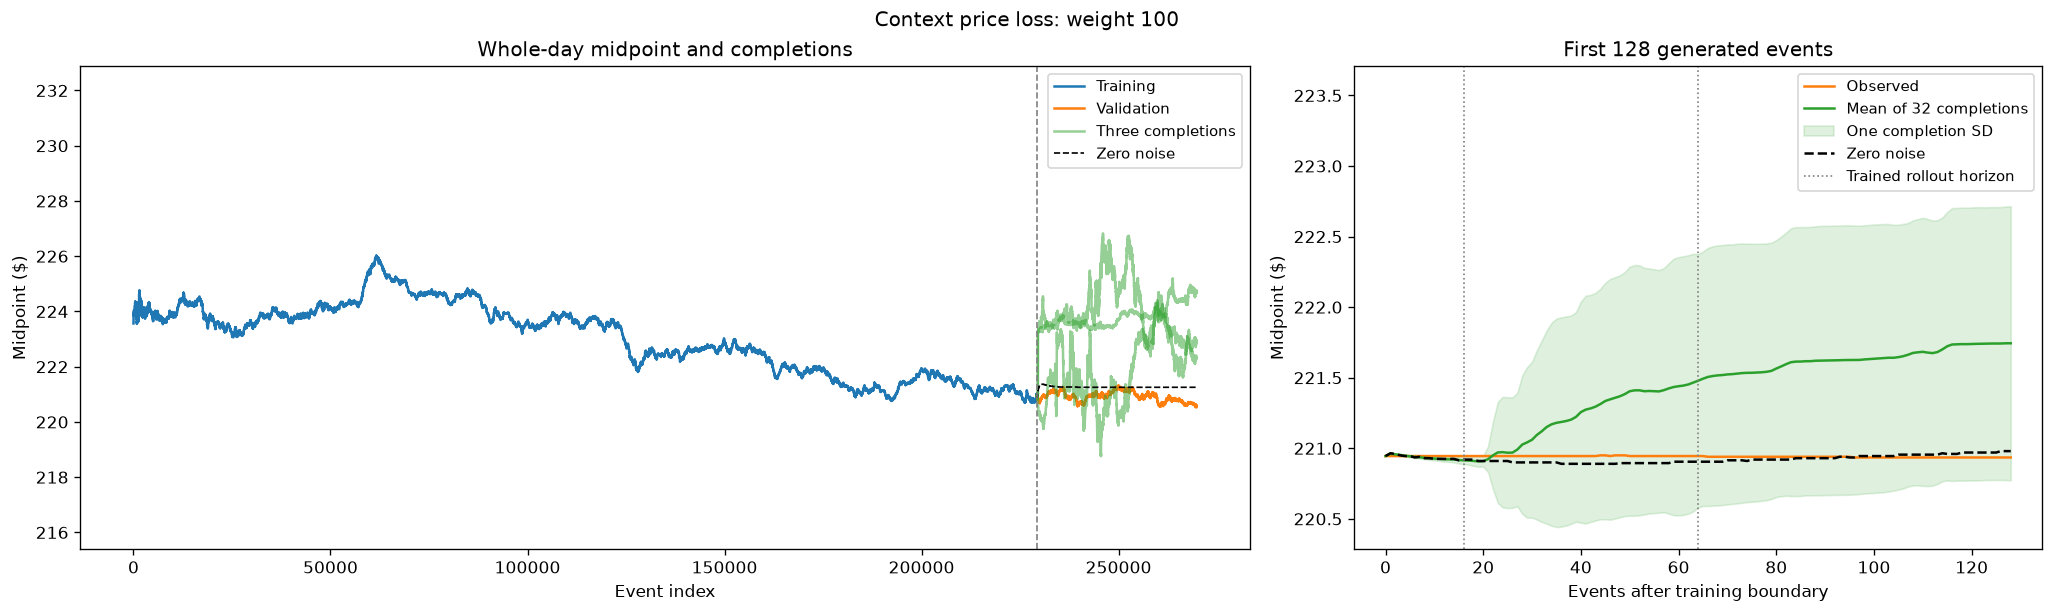

In [7]:
plot_experiment("context_weight_100_horizon_16")


## Does the improvement survive longer training?

The three checkpoints were fixed in advance at 1,000, 2,500, and 5,000 joint
iterations. Do not choose a checkpoint by generator adversarial loss alone.


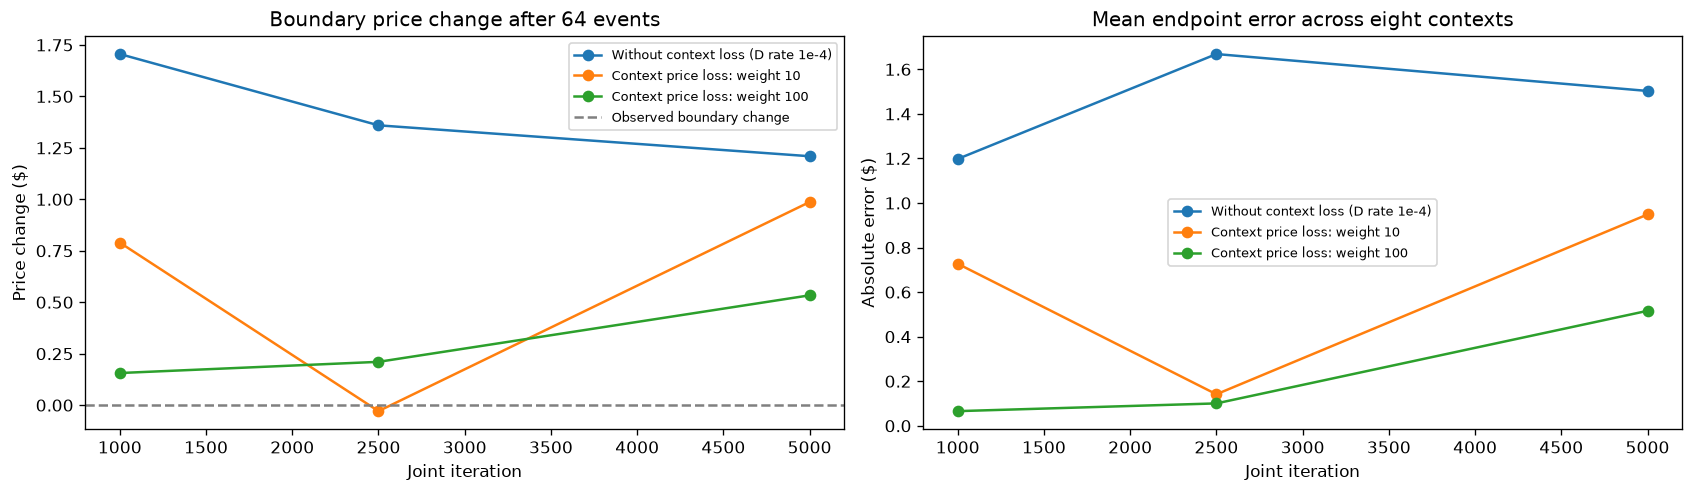

,context_reconstruction_mse,boundary_change_std_dollars,boundary_observed_change_std_dollars,last100_discriminator_loss,last100_generator_adversarial_loss
experiment,,,,,
Without context loss (D rate 1e-4),0.000891,0.024771,0.00125,0.825217,2.178614
Context price loss: weight 10,0.000704,0.010338,0.00125,1.281814,1.479223
Context price loss: weight 100,0.000534,0.072939,0.00125,0.477446,2.228884


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")
for name in EXPERIMENTS:
    rows = snapshots.loc[snapshots["experiment"] == LABELS[name]]
    axes[0].plot(rows["joint_step"], rows["boundary_64_event_change_dollars"],
                 marker="o", label=LABELS[name])
    axes[1].plot(rows["joint_step"], rows["context_mean_abs_64_event_error_dollars"],
                 marker="o", label=LABELS[name])
axes[0].axhline(observed_change, color="gray", linestyle="--", label="Observed boundary change")
axes[0].set(title="Boundary price change after 64 events", xlabel="Joint iteration",
            ylabel="Price change ($)")
axes[1].set(title="Mean endpoint error across eight contexts", xlabel="Joint iteration",
            ylabel="Absolute error ($)")
for ax in axes:
    ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "figures" / "training_progress.png", dpi=140)
plt.show()

display(summary[[
    "context_reconstruction_mse", "boundary_change_std_dollars",
    "boundary_observed_change_std_dollars", "last100_discriminator_loss",
    "last100_generator_adversarial_loss",
]].round(6))


## Ordinary generated-window quality

This secondary check compares generated 64-event windows with real training
windows. Mean, standard-deviation, and event-change errors are averaged across
the 40 standardized features. Lower errors indicate a closer match. This checks
whether reducing the boundary jump comes with poorer ordinary generation.
Training windows are the distribution the unconditional generator was trained
to match; the later validation period has a different price distribution.


In [9]:
import torch
from dataclasses import asdict, is_dataclass
from dataset import WindowDataset
from evaluation import compare_sequences
from predict import generate_features, load_checkpoint

torch.set_num_threads(1)
windows = WindowDataset(training.features, 64, stride=64)
indices = torch.linspace(0, len(windows) - 1, 256).round().long()
real_windows = torch.stack([windows[index.item()] for index in indices])
quality_rows = []
for name in EXPERIMENTS:
    model, _ = load_checkpoint(DIRECTORIES[name] / "model.pt")
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(0)
        generated = generate_features(model, len(real_windows), 64)
    comparison = compare_sequences(real_windows, generated)
    if is_dataclass(comparison):
        comparison = asdict(comparison)
    errors = comparison["absolute_errors"]
    quality_rows.append({
        "experiment": LABELS[name],
        "feature_mean_error": float(errors["mean"]),
        "feature_std_error": float(errors["std"]),
        "feature_change_std_error": float(errors["change_std"]),
        "lag1_correlation_error": float(errors["lag1_correlation"]),
        "midpoint_change_std_ratio": float(comparison["generated"]["change_std"][0]
                                      / comparison["real"]["change_std"][0]),
    })
native_quality = pd.DataFrame(quality_rows).set_index("experiment")
native_quality.to_csv(RESULTS_DIR / "native_window_quality.csv")
display(native_quality.round(6))


,feature_mean_error,feature_std_error,feature_change_std_error,lag1_correlation_error,midpoint_change_std_ratio
experiment,,,,,
Without context loss (D rate 1e-4),0.883565,0.288362,0.297250,0.111787,28.089606
Context price loss: weight 10,1.032912,0.219788,0.327786,0.113717,12.038991
Context price loss: weight 100,0.688990,0.259350,0.351700,0.117191,8.647803


## Measured outcome and limitations

The following comparison is computed from the saved final checkpoints. The
loss aims to correct the initial hand-off. It does not directly train the
random latent initializer or supervise spread, sizes, or gaps. Long runs also
face Wiener input variances larger than those seen within training windows.

At the final checkpoint, **weight 100** reduces the average 16-event endpoint
error across eight contexts from **$0.612 to $0.019**. Its zero-noise 64-event
boundary drift falls from **+$1.065 to -$0.040**. This supports the diagnosis
of an inadequately trained conditional hand-off.

However, noisy 64-event boundary endpoint SD increases from **$0.562 to
$0.898**. Noise-driven drift appears after the supervised 16-event horizon,
and ordinary generated-window midpoint volatility remains excessive. This is
a partial fix. Extending the supervised continuation horizon is a useful next
experiment. Weight 10 also deteriorates late: its mean 64-event boundary
change goes from **-$0.029 at iteration 2,500 to +$0.987 at iteration 5,000**.


In [10]:
from IPython.display import Markdown

reference = summary.loc[LABELS[EXPERIMENTS[0]]]
lines = [f"The reference rises **${reference['boundary_64_event_change_dollars']:.3f}** after 64 events; its mean endpoint error across eight contexts is **${reference['context_mean_abs_64_event_error_dollars']:.3f}**."]
for name in EXPERIMENTS[1:]:
    row = summary.loc[LABELS[name]]
    error_reduction = 100 * (1 - row['context_mean_abs_64_event_error_dollars'] / reference['context_mean_abs_64_event_error_dollars'])
    lines.append(f"**{LABELS[name]}:** first-event change {row['boundary_first_event_change_dollars']:+.4f} dollars; 16-event change {row['boundary_16_event_change_dollars']:+.4f}; 64-event change {row['boundary_64_event_change_dollars']:+.4f}; zero-noise 64-event change {row['boundary_zero_noise_64_event_change_dollars']:+.4f}. Across-context 64-event error is ${row['context_mean_abs_64_event_error_dollars']:.4f}, a {error_reduction:.1f}% reduction from the reference.")
    lines.append(f"Its boundary endpoint spread is ${row['boundary_64_event_std_dollars']:.4f}, versus ${reference['boundary_64_event_std_dollars']:.4f} for the reference. Ordinary generated-window log-midpoint change SD is {native_quality.loc[LABELS[name], 'midpoint_change_std_ratio']:.1f} times the real training value.")
lines.append("These are one-seed comparisons. Small short-horizon drift is encouraging, but the long charts and generated-window statistics must be considered before calling this a realistic conditional model.")
display(Markdown("\n\n".join(lines)))
(RESULTS_DIR / "summary.md").write_text("\n\n".join(lines) + "\n")


The reference rises **$1.209** after 64 events; its mean endpoint error across eight contexts is **$1.503**.

**Context price loss: weight 10:** first-event change -0.0125 dollars; 16-event change +0.2216; 64-event change +0.9869; zero-noise 64-event change +1.1150. Across-context 64-event error is $0.9485, a 36.9% reduction from the reference.

Its boundary endpoint spread is $0.4241, versus $0.5624 for the reference. Ordinary generated-window log-midpoint change SD is 12.0 times the real training value.

**Context price loss: weight 100:** first-event change +0.0158 dollars; 16-event change -0.0305; 64-event change +0.5336; zero-noise 64-event change -0.0400. Across-context 64-event error is $0.5160, a 65.7% reduction from the reference.

Its boundary endpoint spread is $0.8980, versus $0.5624 for the reference. Ordinary generated-window log-midpoint change SD is 8.6 times the real training value.

These are one-seed comparisons. Small short-horizon drift is encouraging, but the long charts and generated-window statistics must be considered before calling this a realistic conditional model.